# ML S2 · Notebook 02 — Metrics, Underfitting and Overfitting

## Machine Learning · Session 2 of 10

| | |
|---|---|
| **Session** | ML S2 — Regression and Regularization |
| **This notebook** | 02 of 3. Regression Metrics · Underfitting & Overfitting. |
| **Block types** | Lecture · **Muscle** (underfitting/overfitting — no AI) |
| **Prerequisites** | Notebook 01 (baselines, linear regression). `housing.csv` in this folder. |
| **Connects forward to** | **ML S3** (the full evaluation session — leakage, cross-validation, "is A really better than B?") · overfitting/regularization → **DL S2** (weight decay, dropout) |
| **Run requirements** | CPU only. `pandas`, `numpy`, `scikit-learn`, `matplotlib`. |

---

### Learning objectives
By the end you can:
1. Compute and **choose between** the core regression metrics — **MAE, MSE, RMSE, R²** — and say when each one misleads you.
2. Tell **underfitting** from **overfitting** on sight — from the shape of a fit, from a train-vs-validation curve, or from the two error numbers alone — and name the fix for each.

> This notebook is the bridge between "I built a model" and "I can *judge* a model." Judging models honestly is the backbone skill of the whole course — we go deep on it in ML S3. Here we get the regression-specific tools you need first.


### Table of contents
1. [Setup](#s0)
2. [Regression metrics: MAE, MSE, RMSE, R²](#s4)
3. [Underfitting and overfitting made visible](#s5)
4. [Wrap-up](#s6)


<a id="s0"></a>
## 0. Setup
Same clean data and a fitted model, so this notebook stands alone.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv("housing.csv")
df = df[(df["bedrooms"] > 0) & (df["sqft"] <= 10_000)].copy()

feature_cols = ["sqft", "bedrooms", "bathrooms", "house_age",
                "garage_spaces", "lot_size", "location_tier"]
X, y = df[feature_cols], df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)
preds = model.predict(X_test)
print("Ready. Test houses:", len(y_test))


Ready. Test houses: 998


<a id="s4"></a>
## 1. Regression metrics: MAE, MSE, RMSE, R²  ·  *~25 min*

### Explanation & intuition
You've been using **MAE** since S1. It's one of several ways to score a number-prediction. Each answers a slightly different question, and choosing the wrong one hides real problems. The four you must know:

| Metric | Full name | Plain-English question | Units |
|---|---|---|---|
| **MAE** | Mean Absolute Error | "On average, how many dollars off?" | dollars |
| **MSE** | Mean Squared Error | "Average of the *squared* errors" | dollars² (not intuitive) |
| **RMSE** | Root Mean Squared Error | "Like MAE, but punishes big misses harder" | dollars |
| **R²** | R-squared | "What fraction of the variation did we explain?" (0–1) | none (a proportion) |

The key distinction: **MAE treats a `$100k` miss as exactly twice as bad as a `$50k` miss.** **RMSE treats it as *four* times as bad** — because it squares the errors before averaging. So RMSE is the one that screams when your model occasionally makes a huge mistake.


> ### 🌱 Just-in-Time — two facts that make these click
> - **RMSE is always ≥ MAE.** Squaring inflates big errors, so the root-mean-square can't come out below the plain average. If RMSE is *much* bigger than MAE, you have a few large misses hiding in an otherwise-okay model.
> - **R² of 0 means "no better than always guessing the mean"** (your baseline from Notebook 01!). R² of 1 means perfect. So R² is literally *"how much better than the baseline, as a fraction."* Negative R² means you're **worse** than the baseline — a real and useful alarm.


In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, preds)
mse  = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, preds)

print(f"MAE:  ${mae:,.0f}   (average dollars off)")
print(f"MSE:  {mse:,.0f}   (dollars squared — hard to read, used to get RMSE)")
print(f"RMSE: ${rmse:,.0f}   (dollars off, big misses weighted heavily)")
print(f"R²:   {r2:.3f}   (fraction of price variation explained)")
print()
print(f"Note RMSE (${rmse:,.0f}) > MAE (${mae:,.0f}) — the gap hints at some large misses.")


MAE:  $180,932   (average dollars off)
MSE:  61,809,585,182   (dollars squared — hard to read, used to get RMSE)
RMSE: $248,615   (dollars off, big misses weighted heavily)
R²:   0.737   (fraction of price variation explained)

Note RMSE ($248,615) > MAE ($180,932) — the gap hints at some large misses.


### Worked example — when MAE looks fine but RMSE exposes trouble
Two models can have the *same MAE* while one is far more dangerous. Watch.


In [3]:
# Model A: consistently off by $30k on every house.
# Model B: usually perfect, but catastrophically wrong on a few houses.
truth   = np.array([300_000] * 20)
model_A = truth + 30_000                     # every prediction $30k high
model_B = truth.copy().astype(float)
model_B[:18] = truth[:18]                     # 18 perfect predictions
model_B[18:] = truth[18:] + 300_000           # 2 wildly wrong (+$300k)

for name, pred in [("Model A (steady $30k off)", model_A),
                   ("Model B (mostly perfect, 2 disasters)", model_B)]:
    a = mean_absolute_error(truth, pred)
    r = np.sqrt(mean_squared_error(truth, pred))
    print(f"{name:<40}  MAE=${a:>7,.0f}   RMSE=${r:>7,.0f}")


Model A (steady $30k off)                 MAE=$ 30,000   RMSE=$ 30,000
Model B (mostly perfect, 2 disasters)     MAE=$ 30,000   RMSE=$ 94,868


Look at the result: the two models have the **same MAE**, but Model B's **RMSE is far higher** — because RMSE punishes those two catastrophic misses. If a few huge errors are dangerous for your use case (e.g. a bank badly misvaluing a property), **RMSE is the metric that catches it and MAE is the one that hides it.** Choosing the metric *is* choosing what kind of mistake you care about.


### 🟢 Try It Yourself — predict which metric moves
Below is a set of predictions that's almost perfect except for **one** enormous error. Before running: *predict whether MAE or RMSE will jump more* when we add that one bad prediction. Then run and check.


In [4]:
truth = np.array([100, 100, 100, 100, 100])
good  = np.array([102,  98, 101,  99, 100])   # all close
bad   = np.array([102,  98, 101,  99, 700])   # last one way off

# Your prediction (write it as a comment): which metric jumps more, MAE or RMSE?

for name, pred in [("all-close", good), ("one-huge-miss", bad)]:
    a = mean_absolute_error(truth, pred)
    r = np.sqrt(mean_squared_error(truth, pred))
    print(f"{name:<15} MAE={a:6.1f}   RMSE={r:6.1f}")


all-close       MAE=   1.2   RMSE=   1.4
one-huge-miss   MAE= 121.2   RMSE= 268.3


<details>
<summary><b>▶ Solution</b></summary>

**RMSE jumps far more than MAE.** Going from "all-close" to "one-huge-miss," MAE rises modestly (one big error averaged among five), but RMSE leaps — because it *squares* that 600-point error before averaging, so the single disaster dominates. This is the whole point: **RMSE is sensitive to outlier errors, MAE is robust to them.** Pick RMSE when big misses are especially costly; pick MAE when you want a stable "typical error" that a few outliers won't distort.
</details>


> ### 🔎 2026 Reality Check
> "Which metric?" is not a default you accept — it's a **design decision** you make against the business cost of being wrong. Is one \$500k blunder worse than ten \$50k ones? Then RMSE. Is steady typical accuracy what matters? Then MAE. This exact judgment — *choosing the measure that matches what you actually care about* — reappears when you evaluate LLM systems in the GenAI course. The tool changes; the discipline doesn't.

> ### ✅ Quick check
> 1. Why is RMSE always greater than or equal to MAE?
> 2. What does an R² of 0 mean, in terms of your baseline from Notebook 01?
> 3. A bank wants to avoid *rare but huge* valuation errors. MAE or RMSE?


<a id="s5"></a>
## 2. Underfitting and Overfitting made visible  ·  *~30 min*  ·  🧠 Muscle block (no AI)

### Explanation & intuition
There are exactly **two ways a model can fail to generalise**, and they are opposites. Everything in this section is about telling them apart.

**Underfitting** is when a model is **too simple** to capture the real pattern. It hasn't learned enough — so it's bad on the training data *and* bad on new data. A straight line trying to describe a curve will never fit, no matter how much data you give it.

> **Analogy:** a student who skims only the chapter headings. Ask them about last year's paper → they do badly. Ask them about this year's → they do just as badly. They never learned the material in the first place.

**Overfitting** is the opposite: a model that is **too flexible** *memorises* its training data — including the random noise — instead of learning the real pattern. It aces the data it has seen and falls apart on anything new.

> **Analogy:** a student who memorises the exact answers to last year's exam papers. Give them last year's paper → 100%. Give them this year's → they collapse, because they learned the answers, not the subject.

Between the two extremes sits the model you want: flexible enough to learn the real structure, too constrained to memorise noise.

| | Underfitting | Just right | Overfitting |
|---|---|---|---|
| **Model is** | too simple / too stiff | balanced | too complex / too flexible |
| **Training error** | high | low | very low (sometimes ~0) |
| **Unseen-data error** | high | low | high |
| **Gap between them** | small | small | **large** |
| **It learned** | too little | the pattern | the noise as well |
| **Formal name** | high **bias** | good trade-off | high **variance** |

You saw both hints of this in S1: a straight-line model that couldn't beat a simple baseline was underfitting; a deep decision tree that scored ~\$0 error on training data and ~\$200k on test data was overfitting. Now let's *look* at them, then watch the transition from one to the other happen gradually.


### See it — three pictures that make both failure modes obvious

Words only go so far here; the two failure modes have *shapes*, and once you've seen them you recognise them for the rest of your career. We build three pictures from scratch:

1. **Picture 1 — the fits.** The same data fitted by a too-stiff, a just-right, and a too-flexible model, side by side.
2. **Picture 2 — the complexity curve.** Training error and unseen error as flexibility increases, with the underfitting and overfitting zones labelled.
3. **Picture 3 — the error signature.** The two numbers side by side for each regime — the pattern you'll actually read off a report.

We use a **small synthetic dataset with a true pattern we choose ourselves** (a sine wave plus noise). That's the trick that makes the lesson visible: because we know the real rule, we can *see* whether the model found it or just traced the noise. Real data never shows you the answer key.

*(Colour convention throughout: **blue = training data / training error**, **orange = unseen data / unseen error**, **grey dashed = the true pattern**, **green = what the model learned**.)*


In [5]:
# A tiny dataset where WE invent the true pattern, so we can check who learned it.
# (In real life the true pattern is unknown — that's exactly why this demo is useful.)
def true_pattern(x):
    return np.sin(x)                       # the real underlying rule

rng   = np.random.default_rng(7)
x_all = np.sort(rng.uniform(0, 6, 26))
y_all = true_pattern(x_all) + rng.normal(0, 0.25, x_all.size)   # + measurement noise

# Every other point trains the model; the rest are held back as "unseen" data.
x_fit, y_fit = x_all[::2],  y_all[::2]     # what the model gets to see
x_new, y_new = x_all[1::2], y_all[1::2]    # what we judge it on

def rmse_score(actual, predicted):
    return float(np.sqrt(np.mean((np.asarray(actual) - np.asarray(predicted)) ** 2)))

# One fixed colour meaning per role, used in all three pictures below.
C_TRAIN  = "#2a78d6"   # blue   — training data / training error
C_UNSEEN = "#eb6834"   # orange — unseen data / unseen error
C_TRUE   = "#52514e"   # grey   — the true pattern
C_FIT    = "#1baf7a"   # green  — what the model learned

print(f"{len(x_fit)} training points, {len(x_new)} unseen points, noise std = 0.25")


13 training points, 13 unseen points, noise std = 0.25


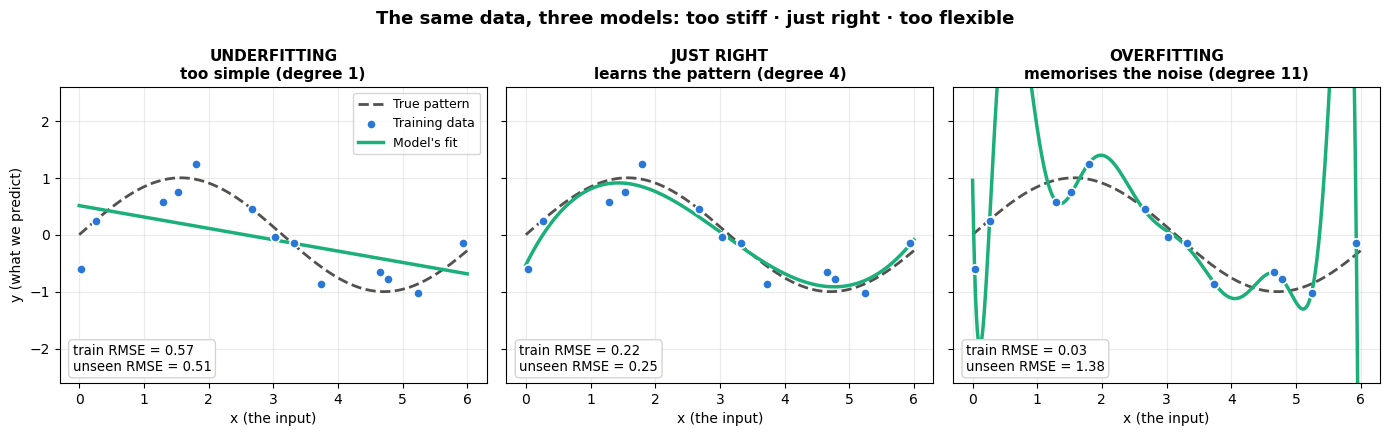

In [6]:
# --- Picture 1: the same data fitted three ways --------------------------------
grid = np.linspace(0, 6, 400)          # a fine x-grid, just for drawing the curves
panels = [(1,  "UNDERFITTING\ntoo simple (degree 1)"),
          (4,  "JUST RIGHT\nlearns the pattern (degree 4)"),
          (11, "OVERFITTING\nmemorises the noise (degree 11)")]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
for ax, (degree, label) in zip(axes, panels):
    coefs = np.polyfit(x_fit, y_fit, degree)      # fit a polynomial of this degree
    ax.plot(grid, true_pattern(grid), "--", color=C_TRUE, lw=2, label="True pattern")
    ax.scatter(x_fit, y_fit, s=45, color=C_TRAIN, zorder=3,
               edgecolor="white", linewidth=1.2, label="Training data")
    ax.plot(grid, np.polyval(coefs, grid), color=C_FIT, lw=2.5, label="Model's fit")

    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("x (the input)")
    ax.text(0.03, 0.03,
            f"train RMSE = {rmse_score(y_fit, np.polyval(coefs, x_fit)):.2f}\n"
            f"unseen RMSE = {rmse_score(y_new, np.polyval(coefs, x_new)):.2f}",
            transform=ax.transAxes, fontsize=9.5, va="bottom",
            bbox=dict(boxstyle="round", fc="white", ec="#d5d4cf"))
    ax.grid(alpha=0.25)
    ax.set_ylim(-2.6, 2.6)             # the degree-11 curve shoots off past this

axes[0].set_ylabel("y (what we predict)")
axes[0].legend(loc="upper right", fontsize=9)
fig.suptitle("The same data, three models: too stiff · just right · too flexible",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**How to read Picture 1** — three fits, one dataset, and the whole lesson:

| Panel | The green fit does this | Training error | Error on unseen data |
|---|---|---|---|
| **Underfitting** (degree 1) | A straight line through a curved pattern — it ignores structure that is plainly there | **high** | **high** |
| **Just right** (degree 4) | Tracks the dashed true pattern, passing *near* the points rather than *through* them | low | **low** |
| **Overfitting** (degree 11) | Bends through the individual points, then flies off between them — it treats noise as signal | **near zero** | **high** |

The two failure modes look nothing alike, and that's the point:
- The underfit model is wrong **in the same way everywhere** — it's too rigid to bend toward the truth (**high bias**).
- The overfit model is wrong **unpredictably** — it follows whichever points it happened to see, so a different sample would give a wildly different curve (**high variance**).
- Only the middle model learned the *rule* rather than the *examples*.

Now watch what happens as we slide flexibility from too-little to too-much, degree by degree.


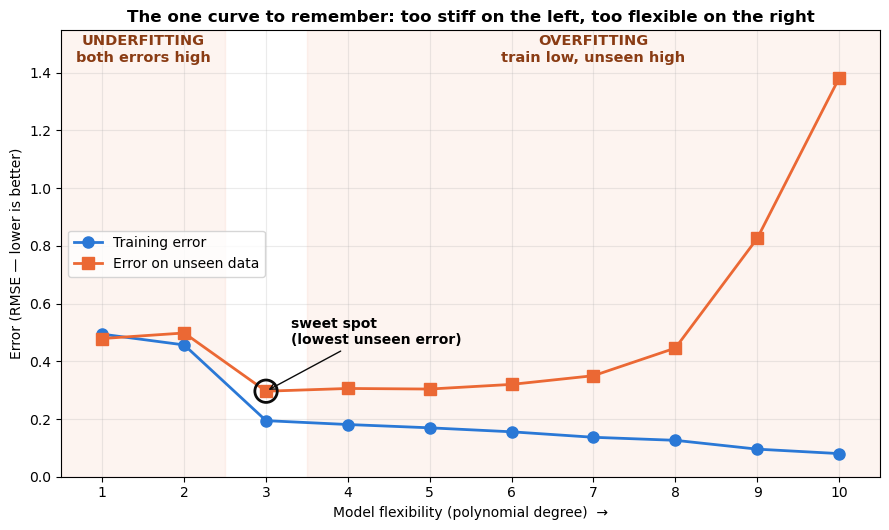

Lowest unseen error at degree 3 — the sweet spot for this data.


In [7]:
# --- Picture 2: the complexity curve, with both failure zones marked ----------
# Sweep flexibility from stiff (degree 1) to very flexible (degree 10) and track
# BOTH errors. We repeat each degree over many random datasets and take the
# median, so the shape is the typical one and not one lucky split.
sweep_degrees = np.arange(1, 11)
train_curve, unseen_curve = [], []

for d in sweep_degrees:
    t_scores, u_scores = [], []
    for seed in range(40):
        r  = np.random.default_rng(seed)
        xs = np.sort(r.uniform(0, 6, 26))
        ys = true_pattern(xs) + r.normal(0, 0.25, xs.size)
        xa, ya, xb, yb = xs[::2], ys[::2], xs[1::2], ys[1::2]   # fit on half, test on half
        c = np.polyfit(xa, ya, d)
        t_scores.append(rmse_score(ya, np.polyval(c, xa)))
        u_scores.append(rmse_score(yb, np.polyval(c, xb)))
    train_curve.append(np.median(t_scores))
    unseen_curve.append(np.median(u_scores))

sweet = int(np.argmin(unseen_curve))
sweet_degree = int(sweep_degrees[sweet])

fig, ax = plt.subplots(figsize=(9, 5.4))
ax.axvspan(0.5, sweet_degree - 0.5, color=C_UNSEEN, alpha=0.07)     # underfitting zone
ax.axvspan(sweet_degree + 0.5, 10.5, color=C_UNSEEN, alpha=0.07)    # overfitting zone
ax.plot(sweep_degrees, train_curve,  "o-", color=C_TRAIN,  lw=2, ms=8, label="Training error")
ax.plot(sweep_degrees, unseen_curve, "s-", color=C_UNSEEN, lw=2, ms=8, label="Error on unseen data")

ax.scatter([sweet_degree], [unseen_curve[sweet]], s=260,
           facecolor="none", edgecolor="#0b0b0b", lw=2, zorder=4)
ax.annotate("sweet spot\n(lowest unseen error)", (sweet_degree, unseen_curve[sweet]),
            textcoords="offset points", xytext=(18, 34), fontsize=10, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#0b0b0b"))

top = max(unseen_curve) * 1.12
ax.text(sweet_degree / 2, top * 0.93, "UNDERFITTING\nboth errors high",
        ha="center", fontsize=10.5, fontweight="bold", color="#8a3c14")
ax.text((sweet_degree + 11) / 2, top * 0.93, "OVERFITTING\ntrain low, unseen high",
        ha="center", fontsize=10.5, fontweight="bold", color="#8a3c14")

ax.set_xlabel("Model flexibility (polynomial degree)  →")
ax.set_ylabel("Error (RMSE — lower is better)")
ax.set_title("The one curve to remember: too stiff on the left, too flexible on the right",
             fontsize=12, fontweight="bold")
ax.set_xlim(0.5, 10.5)
ax.set_ylim(0, top)
ax.set_xticks(sweep_degrees)
ax.grid(alpha=0.25)
ax.legend(loc="center left")
plt.tight_layout()
plt.show()

print(f"Lowest unseen error at degree {sweet_degree} — the sweet spot for this data.")


**How to read Picture 2** — this single curve is the map of the whole problem:
- **Left zone (low flexibility) = underfitting.** Both curves are high *and close together*. The model is too stiff; it hasn't even fit the training data, so adding flexibility helps **both** errors.
- **Right zone (high flexibility) = overfitting.** The training curve keeps drifting down while the unseen curve climbs away from it. The **widening gap** between the two lines is overfitting, drawn to scale.
- **The sweet spot** is the bottom of the unseen-data curve — the last point before extra flexibility starts buying memorisation instead of understanding.

Notice what the **training curve alone** would tell you: "keep going, more flexibility is always better." It never turns up, so it can never warn you. **Only the unseen-data curve knows where to stop** — which is why you always hold data back.

Now the third view: forget the curves and look at just the numbers you'd see in a report.


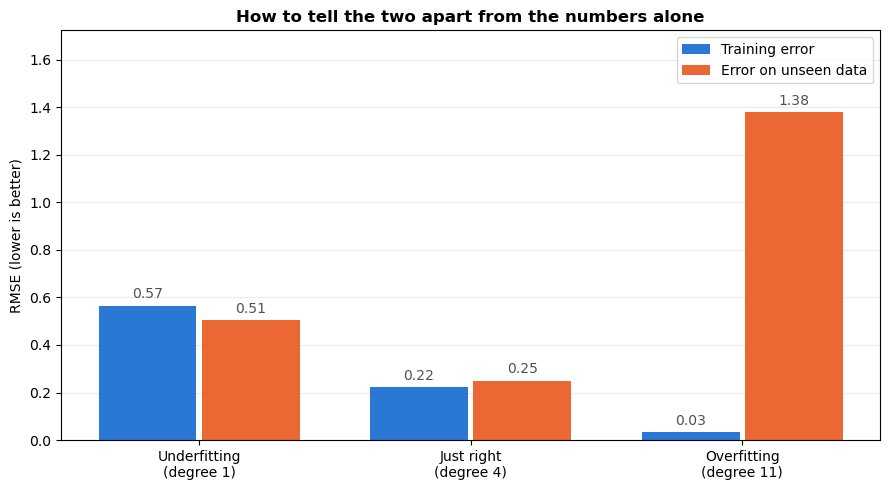

Underfitting : both bars high, and roughly equal   -> too simple
Just right   : both bars low, small gap            -> good generalisation
Overfitting  : training bar tiny, unseen bar huge  -> memorised the noise


In [8]:
# --- Picture 3: the error signature of each failure mode -----------------------
# Same three models, but now only the numbers — this is what you actually see
# in practice, and it's enough to make the diagnosis.
regimes = ["Underfitting\n(degree 1)", "Just right\n(degree 4)", "Overfitting\n(degree 11)"]
fit_err, new_err = [], []
for d in (1, 4, 11):
    coefs = np.polyfit(x_fit, y_fit, d)
    fit_err.append(rmse_score(y_fit, np.polyval(coefs, x_fit)))
    new_err.append(rmse_score(y_new, np.polyval(coefs, x_new)))

pos, width = np.arange(3), 0.36
fig, ax = plt.subplots(figsize=(9, 5))
bars_fit = ax.bar(pos - width/2 - 0.01, fit_err, width, color=C_TRAIN, label="Training error")
bars_new = ax.bar(pos + width/2 + 0.01, new_err, width, color=C_UNSEEN, label="Error on unseen data")
for bars in (bars_fit, bars_new):
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=10, color="#52514e")

ax.set_xticks(pos, regimes)
ax.set_ylabel("RMSE (lower is better)")
ax.set_title("How to tell the two apart from the numbers alone", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(new_err) * 1.25)
ax.grid(alpha=0.25, axis="y")
ax.set_axisbelow(True)
ax.legend()
plt.tight_layout()
plt.show()

print("Underfitting : both bars high, and roughly equal   -> too simple")
print("Just right   : both bars low, small gap            -> good generalisation")
print("Overfitting  : training bar tiny, unseen bar huge  -> memorised the noise")


### The diagnosis table — memorise this, it works for every model you will ever build

| What you see | Diagnosis | What's happening | The fix |
|---|---|---|---|
| Training error **high**, unseen error **high** (and about the same) | **Underfitting** | Model is too stiff to represent the pattern — it hasn't even learned the training data | More flexibility: higher degree, deeper tree, better/more features, train longer, *less* regularization |
| Training error **low**, unseen error **low** (small gap) | **Just right** | Model learned the signal and ignored the noise | Nothing — ship it (then keep monitoring) |
| Training error **very low**, unseen error **high** (big gap) | **Overfitting** | Model memorised the training set, noise included | Less flexibility: lower degree, prune the tree, **regularization** (Notebook 03), more training data |

Two habits fall straight out of this table:
1. **Always look at both numbers.** A single training score can't tell underfitting from overfitting — one has a small gap, the other a huge one, and training error alone shows you neither.
2. **The gap is the tell.** Small gap + high error → too simple. Big gap → too flexible. That's the entire diagnostic, and it's the same in deep learning, gradient boosting, and LLM fine-tuning.

> **The formal names** (you'll hear them constantly): underfitting is **high bias** — the model is systematically wrong because it's too simple. Overfitting is **high variance** — the model swings wildly with whatever data it happened to see. Finding the sweet spot is the **bias–variance trade-off**.


### Worked example — the same sweep on real data (`housing.csv`)
The pictures above used a dataset we invented. Now do it for real: fit models of increasing flexibility (polynomial degree 1, 2, 3, ... up) to the housing data. Low degree = simple, stiff model that risks **underfitting**. High degree = wildly flexible model that risks **overfitting**. We track **training error** and **validation error** as flexibility grows, and watch them diverge.

*(We build this with an explicit loop rather than hiding it in a helper, so you can see every step — the muscle-block way.)*


In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Use a single feature so the overfitting is easy to see and plot.
Xf = df[["sqft"]].values
yf = df["price"].values

X_tr, X_val, y_tr, y_val = train_test_split(Xf, yf, test_size=0.3, random_state=0)

degrees = range(1, 16)
train_rmse, val_rmse = [], []

for d in degrees:
    # Manually: expand features to degree d, then fit linear regression.
    poly = PolynomialFeatures(degree=d)
    X_tr_poly  = poly.fit_transform(X_tr)     # learn+apply expansion on train
    X_val_poly = poly.transform(X_val)        # apply SAME expansion on val

    m = LinearRegression().fit(X_tr_poly, y_tr)

    train_rmse.append(np.sqrt(mean_squared_error(y_tr,  m.predict(X_tr_poly))))
    val_rmse.append(  np.sqrt(mean_squared_error(y_val, m.predict(X_val_poly))))

for d, tr, va in zip(degrees, train_rmse, val_rmse):
    print(f"degree {d:2d}:  train RMSE=${tr:>10,.0f}   val RMSE=${va:>12,.0f}")


degree  1:  train RMSE=$   428,476   val RMSE=$     428,104
degree  2:  train RMSE=$   428,420   val RMSE=$     425,081
degree  3:  train RMSE=$   428,156   val RMSE=$     451,391
degree  4:  train RMSE=$   428,190   val RMSE=$     597,510
degree  5:  train RMSE=$   428,925   val RMSE=$     556,458
degree  6:  train RMSE=$   430,547   val RMSE=$   7,173,086
degree  7:  train RMSE=$   432,931   val RMSE=$  37,773,662
degree  8:  train RMSE=$   435,865   val RMSE=$ 148,281,567
degree  9:  train RMSE=$   439,196   val RMSE=$ 499,119,228
degree 10:  train RMSE=$   442,834   val RMSE=$1,515,836,060
degree 11:  train RMSE=$   446,695   val RMSE=$4,266,941,651
degree 12:  train RMSE=$   450,664   val RMSE=$11,340,925,645
degree 13:  train RMSE=$   454,602   val RMSE=$28,869,762,102
degree 14:  train RMSE=$   458,374   val RMSE=$71,156,639,507
degree 15:  train RMSE=$   461,879   val RMSE=$171,142,014,828


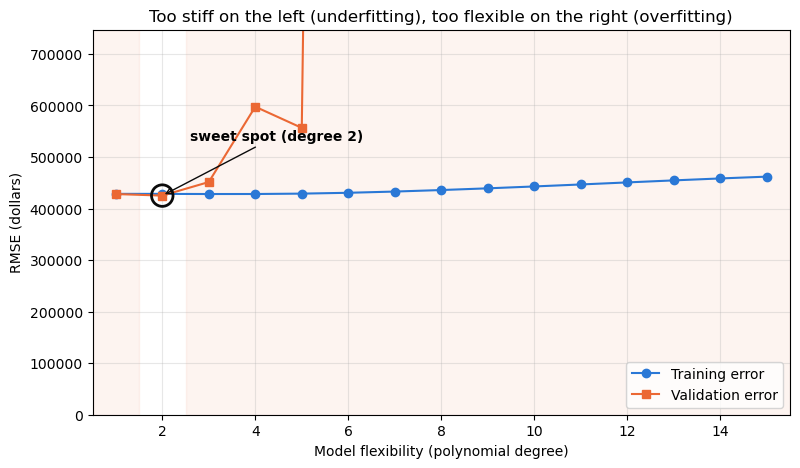

Validation error runs off the top of this zoom from degree 6 onward —
see the printed table above for just how far (billions of dollars of RMSE).


In [10]:
# Plot the two curves — the classic underfitting/overfitting picture, on real data.
best_d = list(degrees)[int(np.argmin(val_rmse))]

plt.figure(figsize=(9, 5))
plt.axvspan(0.5, best_d - 0.5, color="#eb6834", alpha=0.07)          # underfitting zone
plt.axvspan(best_d + 0.5, max(degrees) + 0.5, color="#eb6834", alpha=0.07)   # overfitting zone
plt.plot(list(degrees), train_rmse, "o-", color="#2a78d6", label="Training error")
plt.plot(list(degrees), val_rmse,   "s-", color="#eb6834", label="Validation error")
plt.scatter([best_d], [min(val_rmse)], s=240, facecolor="none", edgecolor="#0b0b0b", lw=2, zorder=4)
plt.annotate(f"sweet spot (degree {best_d})", (best_d, min(val_rmse)),
             textcoords="offset points", xytext=(20, 40), fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#0b0b0b"))
plt.xlabel("Model flexibility (polynomial degree)")
plt.ylabel("RMSE (dollars)")
plt.title("Too stiff on the left (underfitting), too flexible on the right (overfitting)")
plt.legend(loc="lower right")
plt.xlim(0.5, max(degrees) + 0.5)
plt.ylim(0, max(val_rmse[:5]) * 1.25)   # zoom past the blow-up so the turn is visible
plt.grid(alpha=0.3)
plt.show()

print("Validation error runs off the top of this zoom from degree 6 onward —")
print("see the printed table above for just how far (billions of dollars of RMSE).")


Read the picture — this shape is one of the most important in all of machine learning, and it's the same shape you drew on the synthetic data:
- **Training error** keeps falling as the model gets more flexible. Of course — a flexible enough model can wiggle through every training point.
- **Validation error** falls at first (the model is learning real structure), then **turns back up** (the model starts memorising noise that doesn't generalise).
- **Left of the dip you are underfitting** — both errors are high and close together, and more flexibility helps both.
- **Right of the dip you are overfitting** — training error keeps improving while validation error runs away from it.
- The **sweet spot** is the bottom of the validation curve — flexible enough to learn the pattern, not so flexible it memorises noise.

**When both errors are high and similar, you are underfitting. When training error is tiny but validation error is large and rising, you are overfitting.** That pair of tells is the single most important diagnostic in the field.


### 🟢 Try It Yourself — find the sweet spot, and name each side
From the printout and plot above, identify the polynomial degree where **validation error is lowest** on this data — that's the best-generalising model of the bunch. Then say, in your own words, what a model *below* that degree is doing wrong and what a model *above* it is doing wrong.


In [11]:
# Find the degree with the minimum validation RMSE.
best_idx = int(np.argmin(val_rmse))
best_degree = list(degrees)[best_idx]
print(f"Lowest validation error is at degree {best_degree} "
      f"(val RMSE = ${val_rmse[best_idx]:,.0f}).")
print("Beyond that degree, added flexibility hurts — that's overfitting.")


Lowest validation error is at degree 2 (val RMSE = $425,081).
Beyond that degree, added flexibility hurts — that's overfitting.


<details>
<summary><b>▶ What to take away</b></summary>

The exact best degree depends on the data split, but the *shape* is universal: validation error dips to a minimum, then climbs. **Below the minimum the model is underfitting** — too stiff to use the flexibility it's being offered, so both errors stay high. **Above it the model is overfitting** — it spends its extra flexibility on memorising noise, so training error falls while validation error rises. The lesson is not "degree N is magic" — it's the **method**: to find the right complexity, watch the validation curve and stop where it bottoms out. Training error alone will always tell you "more is better," and it will always be lying to you past the sweet spot.
</details>


> ### 🔎 2026 Reality Check
> "Bigger is better" is the loudest myth in modern AI. This curve is exactly *why* it's a myth: past a point, more capacity fits noise, not signal, and generalisation gets **worse**. The same shape governs the biggest models in the world — it's why they need enormous, diverse data and careful regularization to avoid memorising. And the opposite mistake is just as real: a model that's too small for the job **underfits** and no amount of extra data will rescue it. The picture you just drew scales all the way up.

> ### ✅ Quick check
> 1. In one sentence each, what is underfitting and what is overfitting?
> 2. Both your training error and your validation error are high and roughly equal. Which problem is it, and do you make the model *more* or *less* flexible?
> 3. Training error is near zero and validation error is huge. Which problem is it, and what's the fix?
> 4. Why can't you diagnose either problem by looking at training error alone?


<a id="s6"></a>
## 3. Wrap-up

### Common pitfalls
- **Reporting only one metric.** MAE alone can hide catastrophic misses that RMSE would reveal. Look at both.
- **Ignoring R²'s sign.** A negative R² means your model is *worse than the baseline* — a red alert, not a rounding quirk.
- **Trusting training error.** It always improves with complexity and will happily lead you straight into overfitting.
- **Assuming every bad score is overfitting.** If training error is *also* bad, you're **underfitting** — and "add regularization" is exactly the wrong move. Check the gap before you prescribe a cure.
- **Confusing "flexible" with "good."** More capacity is only better up to the validation sweet spot; past it, capacity buys memorisation.

### FAQ
- **Which metric should I report by default?** For most regression, report **MAE and RMSE together** (typical error + sensitivity to big misses), plus **R²** for a scale-free sense of fit. Then pick the one that matches your business cost to *optimise* for.
- **How do I know if I'm underfitting or overfitting?** Compare training error with validation error. Both high and close → underfitting. Training tiny, validation large → overfitting. The **gap** is the diagnostic.
- **Would more data fix my problem?** More data helps **overfitting** (harder to memorise a bigger set) and does almost nothing for **underfitting** (a straight line stays a straight line). Diagnose first, then decide.
- **Is a validation set the same as a test set?** Closely related. Validation is used *during* development to tune choices (like degree here); the test set is touched *once* at the very end. We formalise this three-way split in ML S3.
- **Why did we use a synthetic sine wave for the pictures?** Because we chose the true pattern ourselves, we can *see* whether the model found it or traced the noise. Real data never shows you the answer key — which is why the train-vs-validation gap is your substitute for it.
- **Why did we use only `sqft` for the housing sweep?** One feature makes the effect easy to see and plot. The phenomenon is identical with many features — just harder to visualise.

### Conclusion
You can now judge a regression properly: choose between MAE, RMSE and R² by what kind of error matters, and diagnose the two ways a model fails — **underfitting** (both errors high, model too simple) and **overfitting** (training error tiny, validation error large, model too flexible). You've named both diseases and know which direction each cure runs. The next notebook is the cure for the second one.

### ➡️ Transition to Notebook 03
Overfitting is the problem; **regularization** is the fix — a way to deliberately hold a model back from memorising (and, dialled too far, a way to *cause* underfitting — you'll see both ends). We'll meet Ridge, Lasso and ElasticNet, watch Lasso automatically discover that `garage_spaces` barely matters, and — importantly — learn the **sklearn fit/transform contract** that underpins all preprocessing (and, later, Pipelines). Open **`ML_S2_03_regularization_and_practice.ipynb`**.
